In [13]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\parth\OneDrive\Desktop\german-energy-forecast\DATA\data\final_dataset.csv")

# Convert time column
df["time"] = pd.to_datetime(df["time"])

# ✅ ADD EVERYTHING BELOW HERE

# Sort by time (CRITICAL for time-series)
df = df.sort_values("time")

# Lag features
df["price_lag_1"] = df["price"].shift(1)
df["price_lag_24"] = df["price"].shift(24)

# Rolling average
df["price_rolling_24"] = df["price"].rolling(window=24).mean()

# Time features
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek

# Remove NaN rows caused by lagging
df = df.dropna()

# Now continue your code
df.head()

,time,load,wind,solar,price,price_lag_1,price_lag_24,price_rolling_24,hour,day_of_week
24,2025-01-02 00:00:00,44101.50,41770.50,8.5,2.55,7.01,2.16,0.970833,0,3
25,2025-01-02 01:00:00,42051.75,40984.50,6.5,1.56,2.55,1.60,0.969167,1,3
26,2025-01-02 02:00:00,41234.50,39350.75,6.0,3.45,1.56,0.00,1.112917,2,3
27,2025-01-02 03:00:00,41547.50,38137.50,6.5,7.02,3.45,-0.01,1.405833,3,3
28,2025-01-02 04:00:00,42063.00,35820.00,6.0,12.75,7.02,-0.01,1.937500,4,3


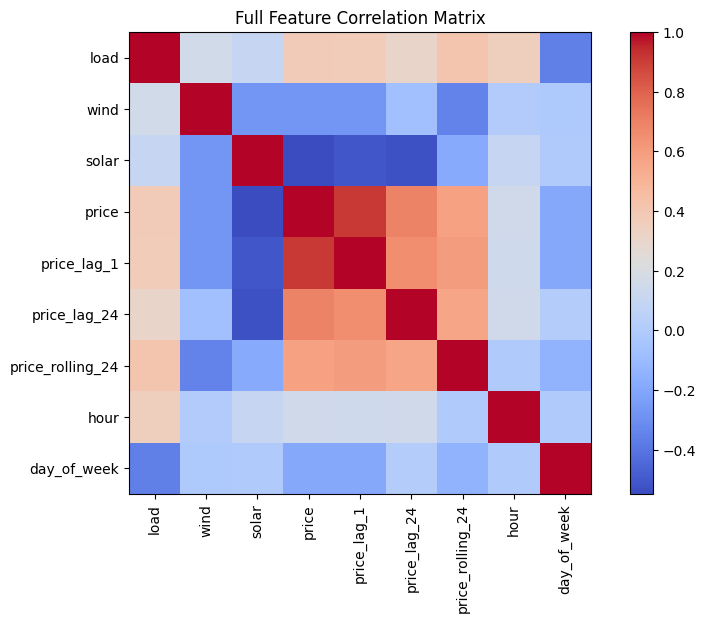

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Full Feature Correlation Matrix")
plt.show()

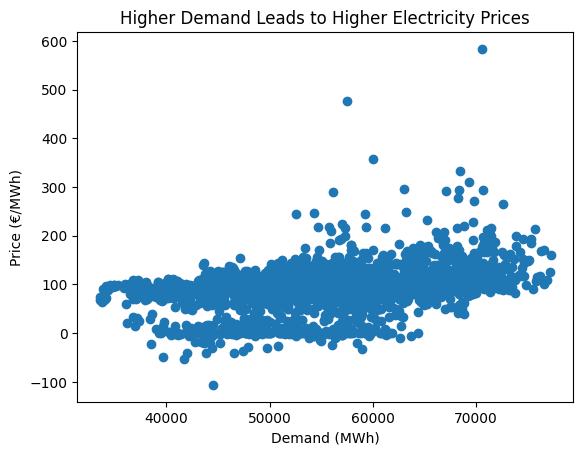

In [10]:
df_sample = df.sample(2000)

plt.figure()
plt.scatter(df_sample["load"], df_sample["price"])
plt.xlabel("Demand (MWh)")
plt.ylabel("Price (€/MWh)")
plt.title("Higher Demand Leads to Higher Electricity Prices")
plt.show()

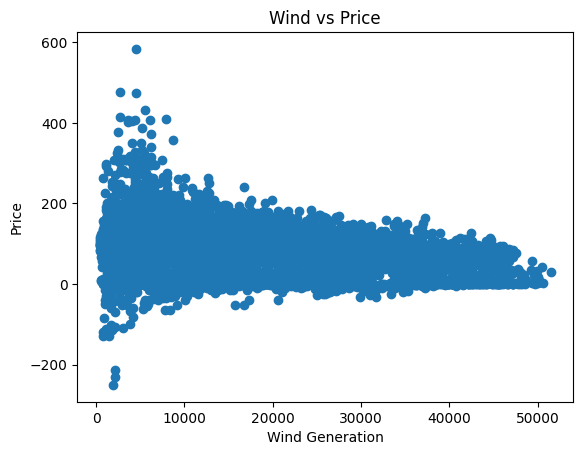

In [7]:
plt.figure()
plt.scatter(df["wind"], df["price"])
plt.xlabel("Wind Generation")
plt.ylabel("Price")
plt.title("Wind vs Price")
plt.show()

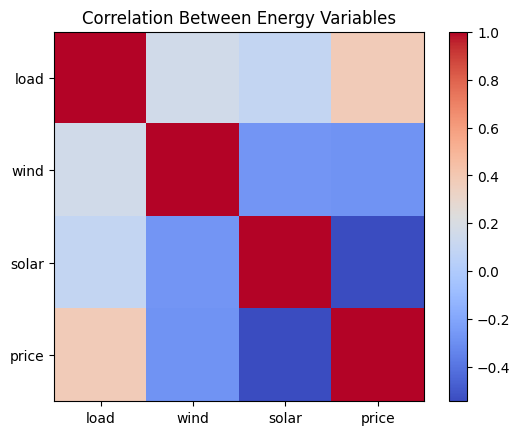

In [11]:
plt.figure()
plt.imshow(df.corr(numeric_only=True), cmap='coolwarm')
plt.colorbar()
plt.xticks(range(4), ["load","wind","solar","price"])
plt.yticks(range(4), ["load","wind","solar","price"])
plt.title("Correlation Between Energy Variables")
plt.show()

In [ ]:
### Key Insights

- Electricity prices increase with demand
- Wind and solar generation reduce electricity prices
- Negative prices occur during high renewable production periods

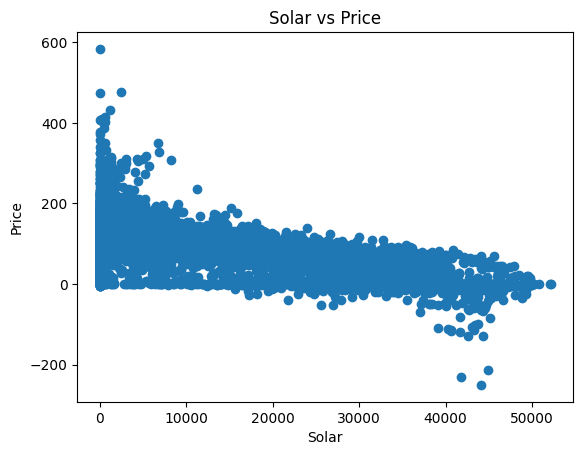

In [8]:
plt.figure()
plt.scatter(df["solar"], df["price"])
plt.xlabel("Solar")
plt.ylabel("Price")
plt.title("Solar vs Price")
plt.show()

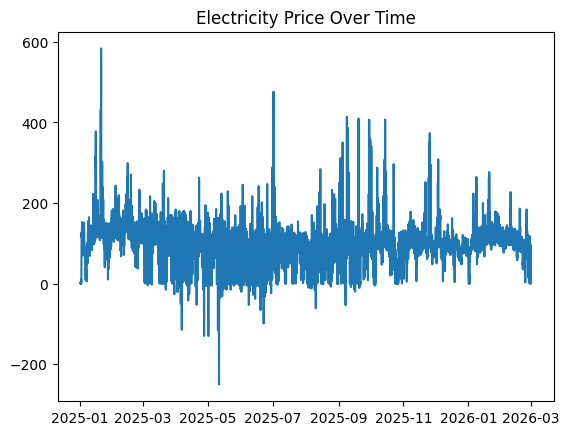

In [9]:
plt.figure()
plt.plot(df["time"], df["price"])
plt.title("Electricity Price Over Time")
plt.show()

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df[[
    "load", "wind", "solar",
    "price_lag_1", "price_lag_24",
    "price_rolling_24",
    "hour", "day_of_week"
]]

# Target
y = df["price"]

# Split
# Time-based split (NO SHUFFLING)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Model
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model trained successfully 🚀")

Model trained successfully 🚀


In [22]:
import pandas as pd
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Evaluation (Linear)
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear MAE:", mean_absolute_error(y_test, predictions))
print("Linear R2:", r2_score(y_test, predictions))


# 🔥 ADD THIS BELOW (Random Forest)

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)


importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_predictions))
print("Random Forest R2:", r2_score(y_test, rf_predictions))

Linear MAE: 9.302549500183474
Linear R2: 0.8587872880691467
            Feature  Importance
3       price_lag_1    0.844980
2             solar    0.043132
6              hour    0.036585
4      price_lag_24    0.026233
0              load    0.016975
1              wind    0.016340
5  price_rolling_24    0.010335
7       day_of_week    0.005419
Random Forest MAE: 5.4487852362204725
Random Forest R2: 0.9346838544611233


In [4]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 11.061948638330396
R2 Score: 0.8762977916712935


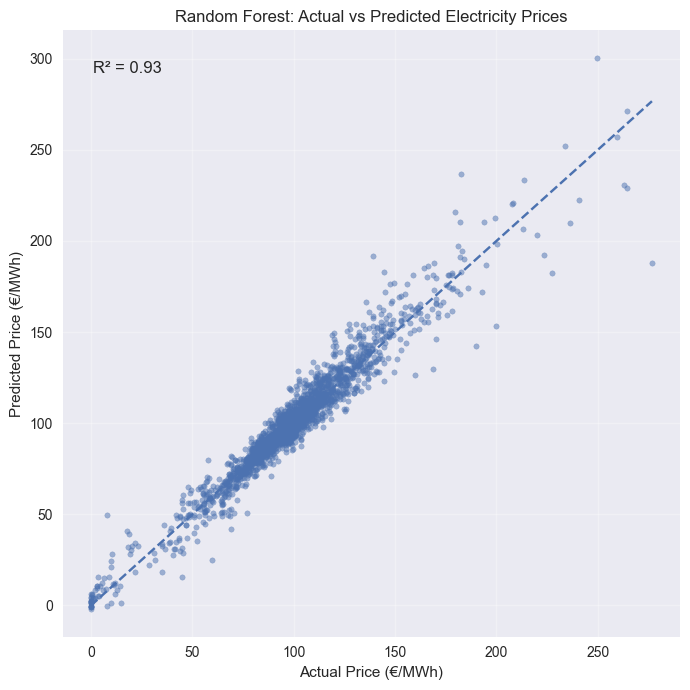

In [20]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_predictions, alpha=0.5, s=15)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Price (€/MWh)")
plt.ylabel("Predicted Price (€/MWh)")
plt.title("Random Forest: Actual vs Predicted Electricity Prices")
plt.text(0.05, 0.95,
         f"R² = {r2_score(y_test, rf_predictions):.2f}",
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

In [6]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_
})

print(coefficients.sort_values(by="Impact", ascending=False))

            Feature    Impact
3       price_lag_1  0.539843
4      price_lag_24  0.125817
6              hour  0.080177
0              load  0.001260
1              wind -0.001226
2             solar -0.001322
5  price_rolling_24 -0.079314
7       day_of_week -0.693204


In [ ]:
df["renewable_ratio"] = (df["wind"] + df["solar"]) / df["load"]

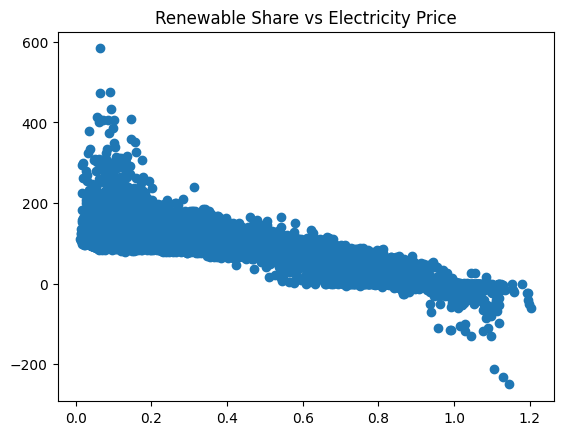

In [ ]:
plt.scatter(df["renewable_ratio"], df["price"])
plt.title("Renewable Share vs Electricity Price")
plt.show()

In [ ]:
df["price_spike"] = df["price"] > df["price"].quantile(0.9)

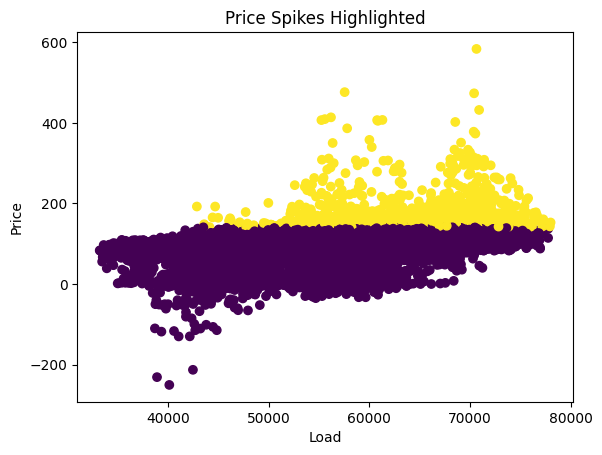

In [ ]:
plt.figure()
plt.scatter(df["load"], df["price"], c=df["price_spike"])
plt.title("Price Spikes Highlighted")
plt.xlabel("Load")
plt.ylabel("Price")
plt.show()

In [ ]:
spike_rate = df["price_spike"].mean()
print("Percentage of high-risk price spikes:", spike_rate * 100, "%")

Percentage of high-risk price spikes: 10.007857002553527 %


In [ ]:
df["renewable_ratio"] = (df["wind"] + df["solar"]) / df["load"]

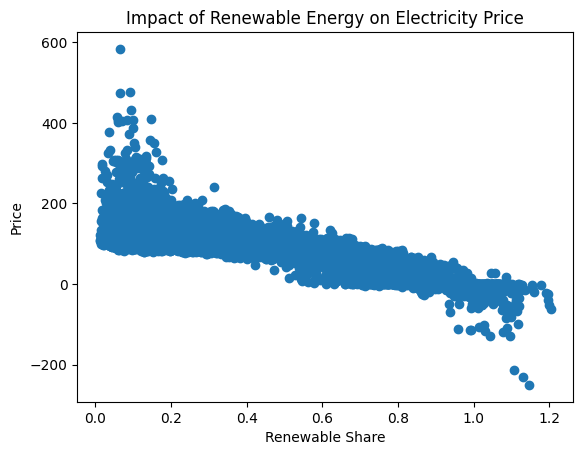

In [ ]:
plt.figure()
plt.scatter(df["renewable_ratio"], df["price"])
plt.xlabel("Renewable Share")
plt.ylabel("Price")
plt.title("Impact of Renewable Energy on Electricity Price")
plt.show()

In [15]:
df["residual_load"] = df["load"] - (df["wind"] + df["solar"])

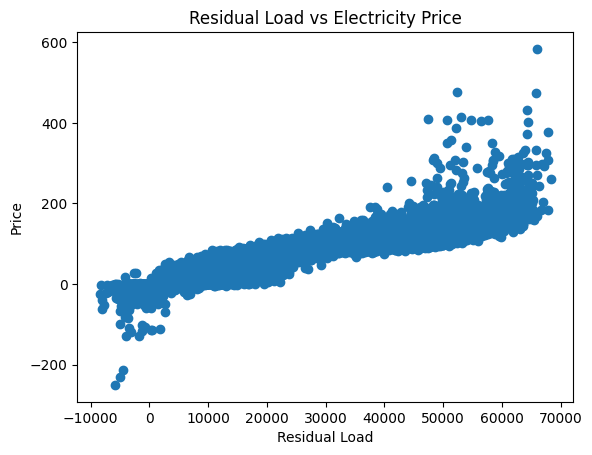

In [16]:
plt.figure()
plt.scatter(df["residual_load"], df["price"])
plt.xlabel("Residual Load")
plt.ylabel("Price")
plt.title("Residual Load vs Electricity Price")
plt.show()